In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

print("모두 정상적으로 불러왔습니다")

모두 정상적으로 불러왔습니다


In [3]:
#전체 구조 요약
df = pd.read_csv("SeoulBikeData.csv", encoding="ISO-8859-1")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-null   str    
dtypes: 

전체 구조 요약 결과 8760개의 행으로 이루어져 있고 결측값은 없다 
데이터의 구조-> str(문자형): 4개 , int64(정수형):4개, float(실수형):6개
Date (str): 날짜가 문자열로 저장되어 있어서, 요일·월 추출을 위해 datetime 타입으로 변환이 필요함 Seasons, Holiday, Functioning_Day (str): 범주형 변수인데 현재 문자열로 저장됨 → 이후 분석 시 category 타입 또는 더미변수로 변환 예정Rented_Bike_Count 등 (int64/float64): 이미 수치형이라 별도 변환 없이 통계 분석에 바로 사용 가능

In [4]:
#이름 간단히 정리
df.columns = [
    "Date", "Rented_Bike_Count", "Hour", "Temperature", "Humidity",
    "Wind_speed", "Visibility", "Dew_point_temperature",
    "Solar_Radiation", "Rainfall", "Snowfall",
    "Seasons", "Holiday", "Functioning_Day"
]

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   8760 non-null   str    
 1   Rented_Bike_Count      8760 non-null   int64  
 2   Hour                   8760 non-null   int64  
 3   Temperature            8760 non-null   float64
 4   Humidity               8760 non-null   int64  
 5   Wind_speed             8760 non-null   float64
 6   Visibility             8760 non-null   int64  
 7   Dew_point_temperature  8760 non-null   float64
 8   Solar_Radiation        8760 non-null   float64
 9   Rainfall               8760 non-null   float64
 10  Snowfall               8760 non-null   float64
 11  Seasons                8760 non-null   str    
 12  Holiday                8760 non-null   str    
 13  Functioning_Day        8760 non-null   str    
dtypes: float64(6), int64(4), str(4)
memory usage: 1.2 MB


In [5]:
# Date를 datetime 타입으로 변환 (2번 파트에서 요일/월 추출 시 사용)
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   8760 non-null   datetime64[us]
 1   Rented_Bike_Count      8760 non-null   int64         
 2   Hour                   8760 non-null   int64         
 3   Temperature            8760 non-null   float64       
 4   Humidity               8760 non-null   int64         
 5   Wind_speed             8760 non-null   float64       
 6   Visibility             8760 non-null   int64         
 7   Dew_point_temperature  8760 non-null   float64       
 8   Solar_Radiation        8760 non-null   float64       
 9   Rainfall               8760 non-null   float64       
 10  Snowfall               8760 non-null   float64       
 11  Seasons                8760 non-null   str           
 12  Holiday                8760 non-null   str           
 13  Functioning_Da

In [6]:
# 컬럼별 결측치 개수
print(df.isnull().sum())

# 전체 결측치 개수
print("전체 결측치:", df.isnull().sum().sum())

# 중복행 개수
print("중복행:", df.duplicated().sum())

Date                     0
Rented_Bike_Count        0
Hour                     0
Temperature              0
Humidity                 0
Wind_speed               0
Visibility               0
Dew_point_temperature    0
Solar_Radiation          0
Rainfall                 0
Snowfall                 0
Seasons                  0
Holiday                  0
Functioning_Day          0
dtype: int64
전체 결측치: 0
중복행: 0


결측치·중복값 없음을 확인

In [7]:
df.describe()

,Date,Rented_Bike_Count,Hour,Temperature,Humidity,Wind_speed,Visibility,Dew_point_temperature,Solar_Radiation,Rainfall,Snowfall
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2018-06-01 00:00:00,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
min,2017-12-01 00:00:00,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,2018-03-02 00:00:00,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,2018-06-01 00:00:00,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,2018-08-31 00:00:00,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,2018-11-30 00:00:00,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000
std,NaN,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746


098% → 0%는 좀 극단적이긴 한데 습도계 특성상 있을 수 있는 값, 날씨 파트에서 자세히 볼 부분 Wind_speed: 0Rented_Bike_Count: 평균 704.6인데 표준편차가 645로 평균과 비슷하게 큼 + 최솟값 0, 최댓값 3556 → 평균과 표준편차가 비슷한 크기라는 건 분포가 대칭이 아니라 한쪽으로 치우쳐 있을 가능성을 시사.
Temperature: -17.8 ~ 39.4도 → 서울의 겨울-여름 기온 범위로 자연스러움, 이상 없음
Humidity: 0~98% → 0%는 좀 극단적이긴 한데 습도계 특성상 있을 수 있는 값, 날씨 파트에서 자세히 볼 부분
Wind_speed: 0~7.4 → 정상 범위
Visibility: 최대 2000에서 값이 몰려있는 걸 보니(75%도 2000) 상한선이 있는 계기(예: 2000이 측정 최댓값)일 가능성 → 이것도 날씨 파트에서 체크 포인트

In [8]:
df.describe(include="all")

,Date,Rented_Bike_Count,Hour,Temperature,Humidity,Wind_speed,Visibility,Dew_point_temperature,Solar_Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning_Day
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760,8760,8760
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,No Holiday,Yes
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2208,8328,8465
mean,2018-06-01 00:00:00,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068,NaN,NaN,NaN
min,2017-12-01 00:00:00,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,2018-03-02 00:00:00,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000,NaN,NaN,NaN
50%,2018-06-01 00:00:00,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000,NaN,NaN,NaN
75%,2018-08-31 00:00:00,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000,NaN,NaN,NaN
max,2018-11-30 00:00:00,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000,NaN,NaN,NaN


범주형 변수들이 모두 예상한 개수(계절 4개, 이진변수 2개씩)로 깨끗하게 되어 있어 —>오타나 이상한 값 없음
Holiday와 Functioning_Day 둘 다 한쪽 범주(No Holiday, Yes)에 크게 치우쳐 있음 -> 나중에 "Holiday별 비교", "Functioning Day별 비교" 분석할 때 표본 불균형을 염두에 둬야 함
Functioning_Day="No"인 295개 행은 대여량이 0에 가까울 가능성이 높음 -> 확인 필요 

In [9]:
# Functioning Day = No인 행들만 추출해서 Rented_Bike_Count 통계 보기
df[df["Functioning_Day"] == "No"]["Rented_Bike_Count"].describe()

count    295.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: Rented_Bike_Count, dtype: float64

Funtioning_Day="No"인 행은 대여량이 모두 0이다. -> 추후에 미운영으로 인한 대여량 '0'의 값을 가지는 데이터들을 어떻게 할지 보기

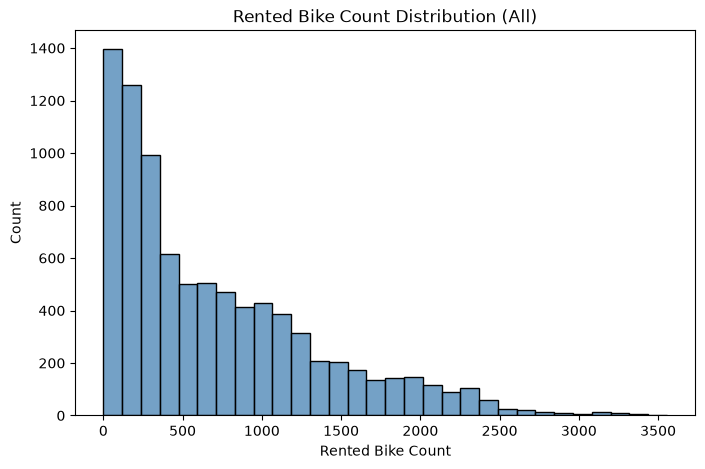

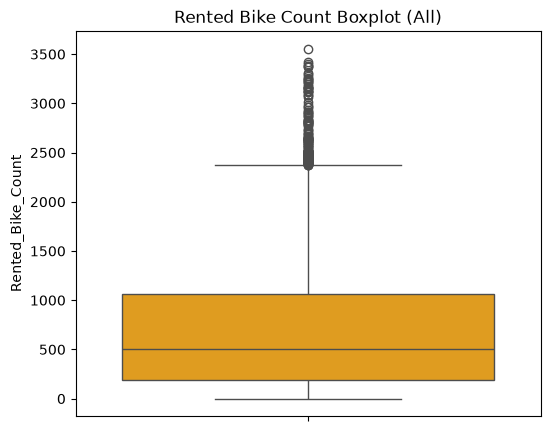

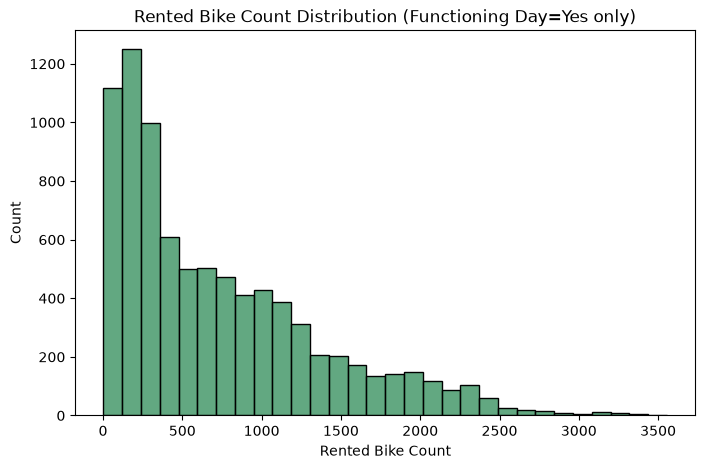

Skewness (All): 1.1532306631480032
Skewness (No excluded): 1.1394980900260392


In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["Rented_Bike_Count"], bins=30, color="steelblue")
plt.title("Rented Bike Count Distribution (All)")
plt.xlabel("Rented Bike Count")
plt.show()

plt.figure(figsize=(6,5))
sns.boxplot(y=df["Rented_Bike_Count"], color="orange")
plt.title("Rented Bike Count Boxplot (All)")
plt.show()

df_yes = df[df["Functioning_Day"] == "Yes"]
plt.figure(figsize=(8,5))
sns.histplot(df_yes["Rented_Bike_Count"], bins=30, color="seagreen")
plt.title("Rented Bike Count Distribution (Functioning Day=Yes only)")
plt.xlabel("Rented Bike Count")
plt.show()

print("Skewness (All):", skew(df["Rented_Bike_Count"]))
print("Skewness (No excluded):", skew(df_yes["Rented_Bike_Count"]))

Rented_Bike_Count는 오른쪽으로 치우친(right-skewed) 분포를 보임(skewness ≈ 1.15)
대부분의 시간대는 낮은 대여량을 보이고 일부 시간대에 높은 대여량이 집중됨
Functioning_Day="No"인 295개 행(대여량 전부 0)을 제외해도 skewness에 유의미한 변화가 없어(1.153→1.139), 이 분포의 치우침은 소수의 구조적 0값 때문이 아니라 자연스러운 수요 패턴 자체에 기인함을 확인함.

In [11]:
Q1 = df["Rented_Bike_Count"].quantile(0.25)
Q3 = df["Rented_Bike_Count"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("하한:", lower_bound)
print("상한:", upper_bound)

outliers = df[(df["Rented_Bike_Count"] < lower_bound) | (df["Rented_Bike_Count"] > upper_bound)]
print("이상치 개수:", len(outliers))

하한: -1120.375
상한: 2376.625
이상치 개수: 158


하한은 신경 쓸 필요 없어짐

In [12]:
outliers[["Date", "Hour", "Rented_Bike_Count", "Temperature", "Seasons", "Holiday"]].sort_values(
    "Rented_Bike_Count", ascending=False
)

,Date,Hour,Rented_Bike_Count,Temperature,Seasons,Holiday
4818,2018-06-19,18,3556,24.1,Summer,No Holiday
4866,2018-06-21,18,3418,27.8,Summer,No Holiday
4650,2018-06-12,18,3404,24.9,Summer,No Holiday
4842,2018-06-20,18,3384,27.0,Summer,No Holiday
4458,2018-06-04,18,3380,24.4,Summer,No Holiday
...,...,...,...,...,...,...
4745,2018-06-16,17,2383,28.4,Summer,No Holiday
3928,2018-05-13,16,2379,19.5,Spring,No Holiday
4821,2018-06-19,21,2378,21.6,Summer,No Holiday
7554,2018-10-11,18,2378,12.1,Autumn,No Holiday


In [39]:
outliers["Hour"].value_counts().sort_index()

Hour
8      4
16     3
17     8
18    87
19    34
20    16
21     6
Name: count, dtype: int64

In [40]:
outliers["Seasons"].value_counts()

Seasons
Summer    89
Autumn    36
Spring    33
Name: count, dtype: int64

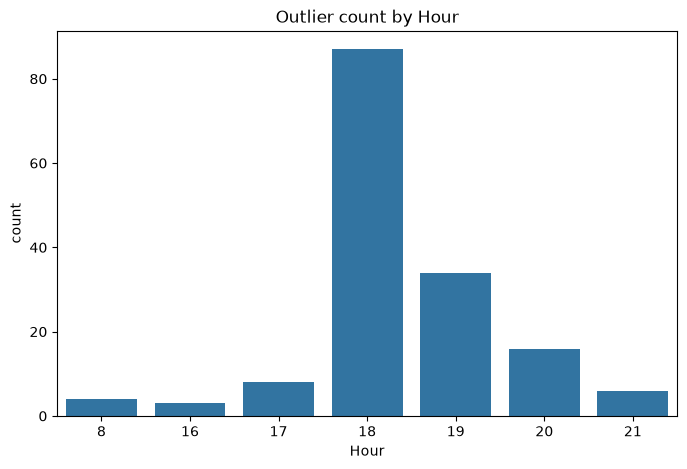

In [41]:
plt.figure(figsize=(8,5))
sns.countplot(x="Hour", data=outliers)
plt.title("Outlier count by Hour")
plt.show()

IQR 기준(1.5×IQR)으로 상한(2376.6) 초과 이상치 158건이 탐지됨
시간대별 분포를 확인한 결과 87건(55%)이 18시, 34건(22%)이 19시에 집중되어 있었음
계절별로도 Summer(89건)에 집중되어 Winter는 0건임
이는 무작위 이상치가 아니라 출퇴근 시간대·활동하기 좋은 계절에 반복적으로 나타나는 구조적 피크 수요로 판단되어, 해당 관측치들을 제거하지 않고 분석에 포함하는것이 좋을 것으로 판단.

1번 파트 최종 요약:결측치 없음, 295개 구조적 0값 처리 필요 논의, 158개 이상치는 유지하기로 함, skewness 1.15로 로그변환 고려 